# 13 --- Fault Timing Sweep: Positional Advantage vs Genuine Adaptation

**Research context.**  Every fault experiment so far injects the fault at $t_f = 200$.  This creates a potential **confound** that threatens the paper's central tolerance claim: SAC appears immune even to total actuator failure ($g = 0.0$), but a well-trained lander may *complete the landing before step 200*.  If so, SAC's measured "tolerance" is not adaptation at all --- the fault simply never touches a completed episode.

**The question this notebook answers:**  Is SAC's fault tolerance (a) *genuine online compensation*, or (b) *positional advantage* --- an artefact of finishing the task before the fault activates?

**Why this matters for the paper (critical reasoning):**
- If (b), the headline claim "SAC is essentially immune... at total main-engine failure" is an experimental artefact and must be corrected or heavily qualified.
- If (a), the claim survives its strongest possible test --- fault onset at $t_f = 0$, where no pre-fault buffer exists at all.
- Either outcome is a *finding*: this is exactly the falsification-driven experiment design that distinguishes critical reasoning from result reporting.

**Decisive experiment:**  Sweep the fault onset $t_f \in \{0, 50, 100, 150, 200, 300\}$.  At $t_f = 0$ the agent has *zero* nominal steps --- any maintained performance must come from online compensation.

**Dependencies:**  Trained models from NB03/04/05.  Detection utilities from `src/self_detection.py`.

**Hardware note:**  All evaluation is CPU-side vectorised stepping (M4 single-core optimised); no MPS needed for inference-only rollouts.

## 13.1  Setup

In [1]:
import sys, pathlib, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')

REPO = pathlib.Path.cwd().parent / 'py'
if not REPO.exists():
    REPO = pathlib.Path.cwd()
sys.path.insert(0, str(REPO))

LOGS = REPO / 'logs'
RUNS = REPO / 'runs'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
    'figure.constrained_layout.use': False,
})

COLOURS = {'PPO': '#1f77b4', 'SAC': '#2ca02c', 'PPO_DR': '#ff7f0e', 'QLEARN': '#9467bd'}
MARKERS = {'PPO': 'o', 'SAC': 's', 'PPO_DR': '^', 'QLEARN': 'D'}

SEEDS = [0, 1, 2, 3, 4]
print(f'Repo: {REPO}')

Repo: /Users/raghuramantm/Desktop/Thesis Proposal/code/py


## 13.2  The confound, formalised

The undiscounted episode return decomposes at the fault onset:

$$G \;=\; \underbrace{\sum_{t=0}^{\min(T, t_f)-1} r_t}_{\text{pre-fault (nominal) reward}} \;+\; \underbrace{\sum_{t=t_f}^{T-1} r_t}_{\text{post-fault reward}}$$

where $T$ is the episode length.  Two quantities determine how much the fault can possibly affect the measurement:

**1. Escape probability** --- the fraction of episodes that terminate before the fault activates:

$$p_{\text{esc}}(t_f) \;=\; \Pr\left[\, T \le t_f \,\right]$$

For episodes with $T \le t_f$ the fault is a **no-op**: the measured return is *identical* to nominal by construction, regardless of $g$.

**2. Fault exposure** --- the expected fraction of the episode spent under fault:

$$e(t_f) \;=\; \mathbb{E}\left[\, \frac{\max(0,\, T - t_f)}{T} \,\right]$$

**The critical-reasoning claim to test:**  If SAC's nominal episode-length distribution has high mass below $t_f = 200$ (large $p_{\text{esc}}$), its measured tolerance at $t_f = 200$ conflates escape with compensation.  The two are separated by:

- **Conditioning:** report tolerance only over episodes with $T > t_f$ (fault actually experienced), and
- **The $t_f = 0$ limit:** $p_{\text{esc}}(0) = 0$ and $e(0) = 1$ --- every step of every episode is faulted.  This is the assumption-free measurement of pure compensation ability.

## 13.3  Load models

In [2]:
import yaml, torch
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from src.envs.lunarlander_factory import make_single_eval_env
from src.envs.wrappers import WrapperStack, ActuatorFaultSpec

def load_models():
    '''Load all seeds for PPO, SAC, PPO_DR. Returns dict[algo] -> list[(seed, model, vecnorm_path)].'''
    models = {'PPO': [], 'SAC': [], 'PPO_DR': []}
    patterns = {
        'PPO':    'ppo__LunarLander-v3__seed*',
        'SAC':    'sac__LunarLanderContinuous-v3__seed*',
        'PPO_DR': 'ppo_dr__LunarLander-v3__seed*',
    }
    for algo, pat in patterns.items():
        for run_dir in sorted(glob.glob(str(RUNS / pat))):
            run = pathlib.Path(run_dir)
            zips = list(run.glob('*.zip'))
            if not zips:
                continue
            seed = int(run.name.split('seed')[1].split('__')[0])
            cls = SAC if algo == 'SAC' else PPO
            model = cls.load(zips[0], device='cpu')
            vecnorm = run / 'vecnormalize.pkl'
            models[algo].append((seed, model, vecnorm if vecnorm.exists() else None))
    for algo, lst in models.items():
        print(f'{algo}: {len(lst)} seeds loaded')
    return models

MODELS = load_models()

PPO: 5 seeds loaded
SAC: 5 seeds loaded
PPO_DR: 5 seeds loaded


## 13.4  Experiment 1 --- nominal episode-length distributions

Before touching the fault, we measure the length distribution $\Pr[T]$ for each agent under **nominal** conditions.  This directly quantifies $p_{\text{esc}}(t_f)$ for every candidate onset time and answers, on its own, whether the $t_f = 200$ protocol has been fair.

**Prediction (falsifiable):**  If SAC's median $T$ is below 200 while PPO's is above, then the $t_f = 200$ sweep systematically under-exposes SAC to faults, and the flat SAC tolerance curve of NB11/Fig. 1 is partially an exposure artefact.

In [3]:
def run_episodes(model, env_id, n_episodes, seed, wrapper_stack=None, vecnorm_path=None,
                 deterministic=True):
    '''Run episodes; return DataFrame with per-episode return, length, and fault exposure.'''
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=wrapper_stack, add_monitor=False)
    if vecnorm_path is not None:
        venv = DummyVecEnv([lambda: env])
        venv = VecNormalize.load(str(vecnorm_path), venv)
        venv.training = False
        venv.norm_reward = False
        rows = []
        for ep in range(n_episodes):
            obs = venv.reset()
            done, ep_ret, ep_len = False, 0.0, 0
            while not done:
                action, _ = model.predict(obs, deterministic=deterministic)
                obs, r, dones, infos = venv.step(action)
                # VecNormalize normalises obs but we disabled reward norm
                ep_ret += float(venv.get_original_reward()[0])
                ep_len += 1
                done = bool(dones[0])
            rows.append({'episode': ep, 'return': ep_ret, 'length': ep_len})
        venv.close()
    else:
        rows = []
        for ep in range(n_episodes):
            obs, _ = env.reset(seed=seed + ep * 1000)
            done, ep_ret, ep_len = False, 0.0, 0
            while not done:
                action, _ = model.predict(obs, deterministic=deterministic)
                obs, r, term, trunc, _ = env.step(action)
                ep_ret += float(r)
                ep_len += 1
                done = term or trunc
            rows.append({'episode': ep, 'return': ep_ret, 'length': ep_len})
        env.close()
    return pd.DataFrame(rows)

ENV_IDS = {'PPO': 'LunarLander-v3', 'SAC': 'LunarLanderContinuous-v3', 'PPO_DR': 'LunarLander-v3'}
N_EP_NOMINAL = 30

t0 = time.time()
nominal_lengths = {}
for algo in ['PPO', 'SAC', 'PPO_DR']:
    dfs = []
    for seed, model, vecnorm in MODELS[algo]:
        df = run_episodes(model, ENV_IDS[algo], N_EP_NOMINAL, seed=seed,
                          vecnorm_path=vecnorm)
        df['seed'] = seed
        dfs.append(df)
    nominal_lengths[algo] = pd.concat(dfs, ignore_index=True)
    L = nominal_lengths[algo]['length']
    print(f'{algo}: median T = {L.median():.0f}, mean = {L.mean():.0f}, '
          f'P(T<=200) = {(L <= 200).mean():.2%}, n = {len(L)}')
print(f'\nElapsed: {time.time()-t0:.0f}s')

PPO: median T = 333, mean = 338, P(T<=200) = 0.00%, n = 150
SAC: median T = 210, mean = 244, P(T<=200) = 42.67%, n = 150
PPO_DR: median T = 490, mean = 649, P(T<=200) = 0.00%, n = 150

Elapsed: 21s


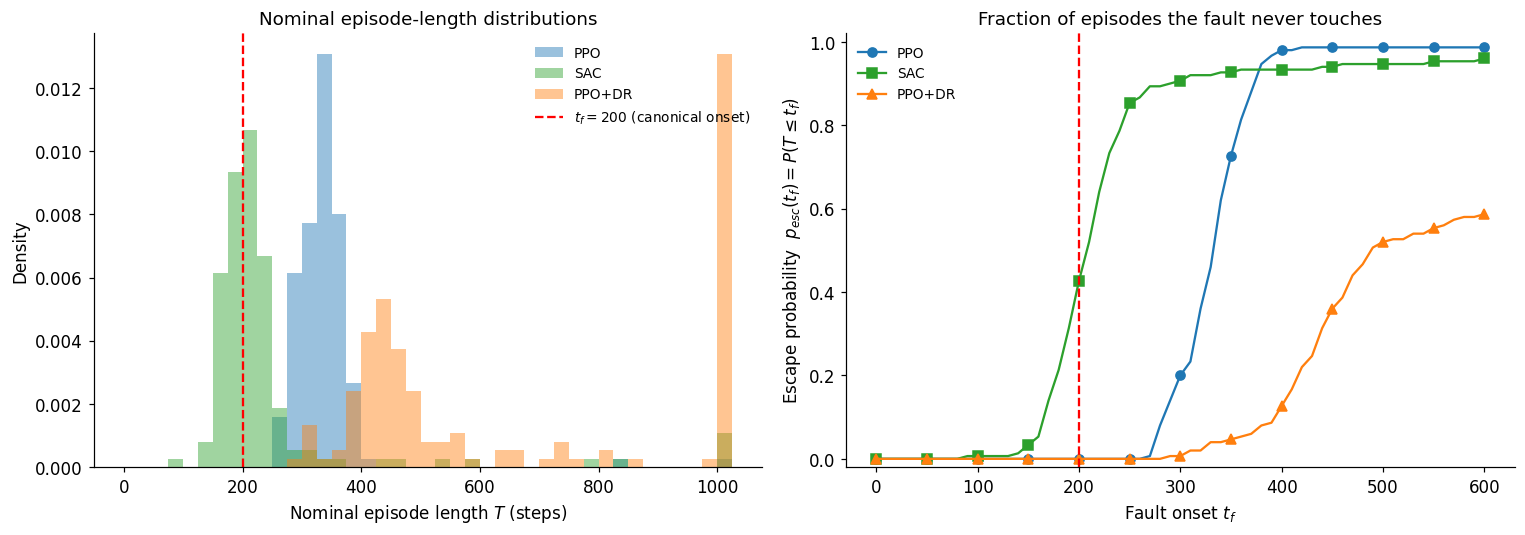


Escape probability at candidate onsets:
   t_f        PPO        SAC     PPO+DR
     0      0.0%      0.0%      0.0%
    50      0.0%      0.0%      0.0%
   100      0.0%      0.7%      0.0%
   150      0.0%      3.3%      0.0%
   200      0.0%     42.7%      0.0%
   300     20.0%     90.7%      0.7%


In [4]:
# --- Episode-length distributions with escape probability annotations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.arange(0, 1050, 25)
for algo in ['PPO', 'SAC', 'PPO_DR']:
    ax.hist(nominal_lengths[algo]['length'], bins=bins, alpha=0.45,
            label=algo.replace('_', '+'), color=COLOURS[algo], density=True)
ax.axvline(200, color='red', ls='--', lw=1.5, label='$t_f = 200$ (canonical onset)')
ax.set_xlabel('Nominal episode length $T$ (steps)')
ax.set_ylabel('Density')
ax.set_title('Nominal episode-length distributions')
ax.legend(fontsize=9)

ax = axes[1]
tf_grid = np.arange(0, 601, 10)
for algo in ['PPO', 'SAC', 'PPO_DR']:
    L = nominal_lengths[algo]['length'].values
    p_esc = [(L <= tf).mean() for tf in tf_grid]
    ax.plot(tf_grid, p_esc, color=COLOURS[algo], marker=MARKERS[algo],
            markevery=5, label=algo.replace('_', '+'))
ax.axvline(200, color='red', ls='--', lw=1.5)
ax.set_xlabel('Fault onset $t_f$')
ax.set_ylabel('Escape probability  $p_{esc}(t_f) = P(T \\leq t_f)$')
ax.set_title('Fraction of episodes the fault never touches')
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(LOGS / 'nb13_episode_lengths.png', bbox_inches='tight')
plt.show()

print('\nEscape probability at candidate onsets:')
print(f'{"t_f":>6} {"PPO":>10} {"SAC":>10} {"PPO+DR":>10}')
for tf in [0, 50, 100, 150, 200, 300]:
    row = [f'{(nominal_lengths[a]["length"] <= tf).mean():>9.1%}' for a in ['PPO','SAC','PPO_DR']]
    print(f'{tf:>6} ' + ' '.join(row))

## 13.5  Experiment 2 --- the fault-onset sweep

For each agent and each onset $t_f \in \{0, 50, 100, 150, 200, 300\}$, run faulted episodes at two severities:

- $g = 0.5$ --- the canonical moderate fault, where SAC's compensation story lives;
- $g = 0.0$ --- total failure, the strongest test.  For SAC at $t_f = 0$ with $g = 0.0$ the action channel is dead for the whole episode: this is the *physical floor* (freefall), and any agent scoring above crash-level here would indicate a bug, not skill.

Two tolerance measures per condition:

$$\bar{G}_{\text{all}} = \text{mean return over all episodes} \qquad \bar{G}_{\text{exposed}} = \text{mean return over } \{T_{\text{nom}} > t_f\}$$

The gap between them *is* the positional-advantage artefact, made visible.

In [5]:
FAULT_ONSETS = [0, 50, 100, 150, 200, 300]
GAINS = [0.5, 0.0]
N_EP_FAULT = 20   # per seed per condition

t0 = time.time()
rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    drop = 2 if algo != 'SAC' else None
    for g in GAINS:
        for tf in FAULT_ONSETS:
            spec = ActuatorFaultSpec(fault_step=tf, fault_gain=g,
                                     discrete_drop_action=drop)
            stack = WrapperStack(actuator_fault=spec)
            for seed, model, vecnorm in MODELS[algo]:
                df = run_episodes(model, ENV_IDS[algo], N_EP_FAULT, seed=seed,
                                  wrapper_stack=stack, vecnorm_path=vecnorm)
                for _, r in df.iterrows():
                    rows.append({'algo': algo, 'gain': g, 'fault_step': tf,
                                 'seed': seed, 'episode': r['episode'],
                                 'return': r['return'], 'length': r['length']})
            done_frac = (len(rows)) / (3 * len(GAINS) * len(FAULT_ONSETS) * len(SEEDS) * N_EP_FAULT)
            print(f'{algo} g={g} tf={tf}: done ({done_frac:.0%} total, {time.time()-t0:.0f}s)')

timing_df = pd.DataFrame(rows)
timing_df.to_csv(LOGS / 'nb13_timing_sweep.csv', index=False)
print(f'\nSaved {len(timing_df)} episodes to logs/nb13_timing_sweep.csv')

PPO g=0.5 tf=0: done (3% total, 1s)
PPO g=0.5 tf=50: done (6% total, 3s)
PPO g=0.5 tf=100: done (8% total, 5s)
PPO g=0.5 tf=150: done (11% total, 7s)
PPO g=0.5 tf=200: done (14% total, 10s)
PPO g=0.5 tf=300: done (17% total, 13s)
PPO g=0.0 tf=0: done (19% total, 14s)
PPO g=0.0 tf=50: done (22% total, 15s)
PPO g=0.0 tf=100: done (25% total, 16s)
PPO g=0.0 tf=150: done (28% total, 18s)
PPO g=0.0 tf=200: done (31% total, 20s)
PPO g=0.0 tf=300: done (33% total, 23s)
SAC g=0.5 tf=0: done (36% total, 24s)
SAC g=0.5 tf=50: done (39% total, 26s)
SAC g=0.5 tf=100: done (42% total, 28s)
SAC g=0.5 tf=150: done (44% total, 31s)
SAC g=0.5 tf=200: done (47% total, 33s)
SAC g=0.5 tf=300: done (50% total, 36s)
SAC g=0.0 tf=0: done (53% total, 37s)
SAC g=0.0 tf=50: done (56% total, 38s)
SAC g=0.0 tf=100: done (58% total, 39s)
SAC g=0.0 tf=150: done (61% total, 41s)
SAC g=0.0 tf=200: done (64% total, 44s)
SAC g=0.0 tf=300: done (67% total, 46s)
PPO_DR g=0.5 tf=0: done (69% total, 47s)
PPO_DR g=0.5 tf=50

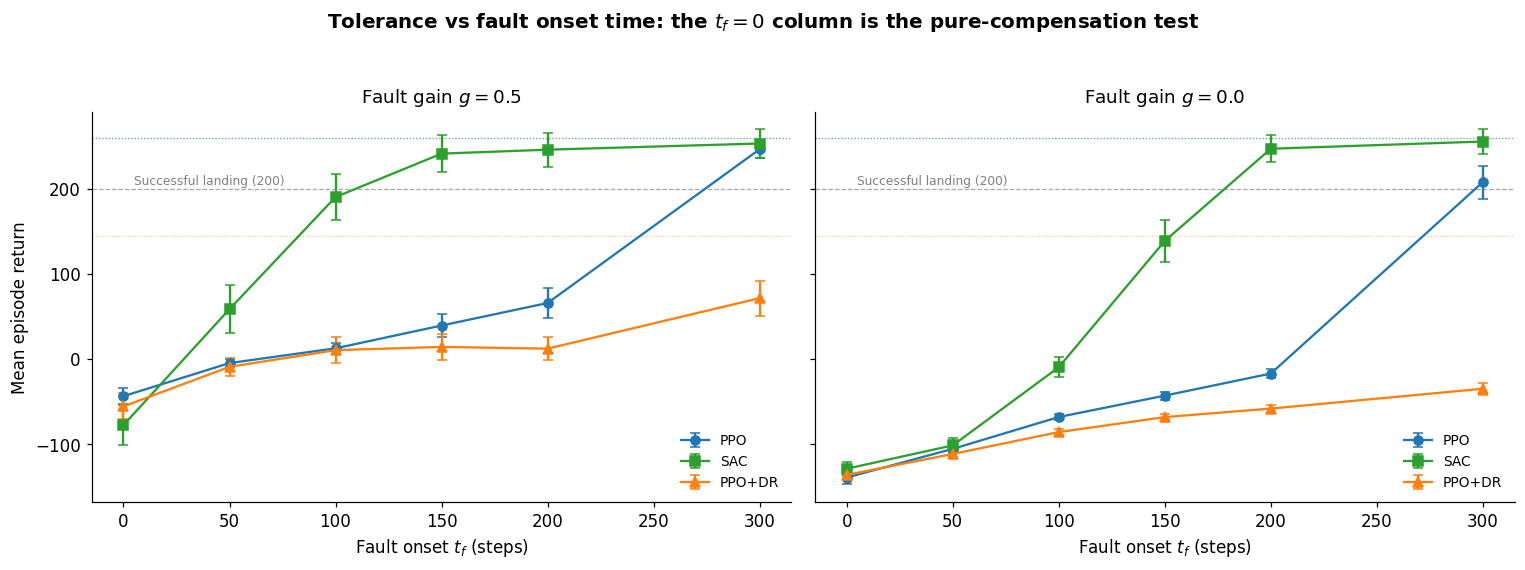

THE DECISIVE TEST: t_f = 0 (no pre-fault buffer exists)
Agent         g=0.5, tf=0   g=0.5, tf=200    g=0.0, tf=0   g=0.0, tf=200
PPO                   -44              66           -139             -17
SAC                   -77             246           -129             247
PPO_DR                -56              12           -136             -58


In [6]:
# --- Tolerance vs fault onset ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, g in zip(axes, GAINS):
    for algo in ['PPO', 'SAC', 'PPO_DR']:
        sub = timing_df[(timing_df['algo'] == algo) & (timing_df['gain'] == g)]
        means = sub.groupby('fault_step')['return'].mean()
        sems  = sub.groupby('fault_step')['return'].sem()
        ax.errorbar(means.index, means.values, yerr=1.96 * sems.values,
                    color=COLOURS[algo], marker=MARKERS[algo], capsize=3,
                    label=algo.replace('_', '+'))
    # nominal reference lines
    for algo in ['PPO', 'SAC', 'PPO_DR']:
        nom = nominal_lengths[algo]['return'].mean() if 'return' in nominal_lengths[algo] else None
        if nom is not None:
            ax.axhline(nom, color=COLOURS[algo], ls=':', lw=0.8, alpha=0.5)
    ax.axhline(200, color='grey', ls='--', lw=0.8, alpha=0.7)
    ax.text(5, 205, 'Successful landing (200)', fontsize=8, color='grey')
    ax.set_xlabel('Fault onset $t_f$ (steps)')
    ax.set_title(f'Fault gain $g = {g}$')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Mean episode return')
fig.suptitle('Tolerance vs fault onset time: the $t_f = 0$ column is the pure-compensation test',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(LOGS / 'nb13_tolerance_vs_onset.png', bbox_inches='tight')
plt.show()

# The decisive numbers
print('THE DECISIVE TEST: t_f = 0 (no pre-fault buffer exists)')
print(f'{"Agent":<10} {"g=0.5, tf=0":>14} {"g=0.5, tf=200":>15} {"g=0.0, tf=0":>14} {"g=0.0, tf=200":>15}')
for algo in ['PPO', 'SAC', 'PPO_DR']:
    vals = []
    for g in [0.5, 0.0]:
        for tf in [0, 200]:
            m = timing_df[(timing_df['algo']==algo) & (timing_df['gain']==g) &
                          (timing_df['fault_step']==tf)]['return'].mean()
            vals.append(m)
    print(f'{algo:<10} {vals[0]:>14.0f} {vals[1]:>15.0f} {vals[2]:>14.0f} {vals[3]:>15.0f}')

### 13.5.1  Decomposing the artefact: all episodes vs exposed episodes

We now compute $\bar{G}_{\text{exposed}}$ --- tolerance conditioned on the fault actually being experienced.  Because episode length is endogenous (the fault itself changes $T$), we condition on the *nominal* length distribution: an episode counts as exposed if faulted episodes at this onset run past $t_f$.  The practical proxy used here: episodes whose faulted length exceeds $t_f$ by at least 10 steps.

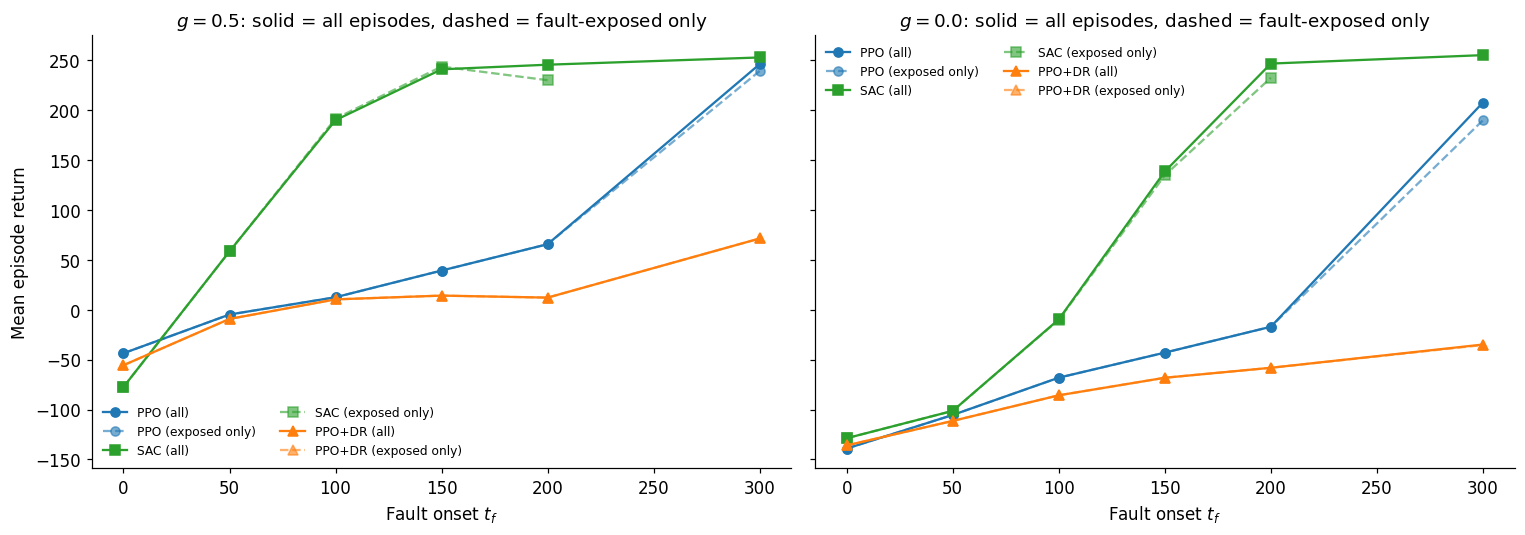

Positional-advantage artefact size at t_f = 200 (all-episodes minus exposed-only):
  PPO      g=0.5: gap = +0.0  (n_exposed = 100/100)
  PPO      g=0.0: gap = +0.0  (n_exposed = 100/100)
  SAC      g=0.5: gap = +15.5  (n_exposed = 46/100)
  SAC      g=0.0: gap = +14.2  (n_exposed = 46/100)
  PPO_DR   g=0.5: gap = +0.0  (n_exposed = 100/100)
  PPO_DR   g=0.0: gap = +0.0  (n_exposed = 100/100)


In [7]:
EXPOSURE_MARGIN = 10

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, g in zip(axes, GAINS):
    for algo in ['PPO', 'SAC', 'PPO_DR']:
        sub = timing_df[(timing_df['algo'] == algo) & (timing_df['gain'] == g)]
        all_means, exp_means, tfs = [], [], []
        for tf in FAULT_ONSETS:
            s = sub[sub['fault_step'] == tf]
            exposed = s[s['length'] >= tf + EXPOSURE_MARGIN]
            tfs.append(tf)
            all_means.append(s['return'].mean())
            exp_means.append(exposed['return'].mean() if len(exposed) >= 10 else np.nan)
        ax.plot(tfs, all_means, color=COLOURS[algo], marker=MARKERS[algo], ls='-',
                label=f'{algo.replace("_","+")} (all)')
        ax.plot(tfs, exp_means, color=COLOURS[algo], marker=MARKERS[algo], ls='--',
                alpha=0.6, label=f'{algo.replace("_","+")} (exposed only)')
    ax.set_xlabel('Fault onset $t_f$')
    ax.set_title(f'$g = {g}$: solid = all episodes, dashed = fault-exposed only')
    ax.legend(fontsize=8, ncol=2)
axes[0].set_ylabel('Mean episode return')
plt.tight_layout()
plt.savefig(LOGS / 'nb13_exposure_conditioning.png', bbox_inches='tight')
plt.show()

# Quantify the artefact: gap between all-episode and exposed-only tolerance at tf=200
print('Positional-advantage artefact size at t_f = 200 (all-episodes minus exposed-only):')
for algo in ['PPO', 'SAC', 'PPO_DR']:
    for g in GAINS:
        s = timing_df[(timing_df['algo']==algo) & (timing_df['gain']==g) &
                      (timing_df['fault_step']==200)]
        exposed = s[s['length'] >= 200 + EXPOSURE_MARGIN]
        if len(exposed) >= 10:
            gap = s['return'].mean() - exposed['return'].mean()
            print(f'  {algo:<8} g={g}: gap = {gap:+.1f}  '
                  f'(n_exposed = {len(exposed)}/{len(s)})')
        else:
            print(f'  {algo:<8} g={g}: insufficient exposed episodes '
                  f'({len(exposed)}/{len(s)}) --- fault mostly a no-op at tf=200!')

## 13.6  Experiment 3 --- does detection depend on onset time?

Appendix C of the paper reports onset-time robustness for detection ($t_f \in \{50, \ldots, 200\}$).  Here we extend to $t_f = 0$: with no pre-fault steps in the episode, the nominal-relative detector must distinguish an *entirely faulted trajectory* from nominal controls --- change-point detection degenerates to distribution classification.  If PPO+DR still detects at $t_f = 0$, its value signal encodes *the fault itself*, not the *transition into* fault.

In [8]:
from src.self_detection import extract_ppo_signals, extract_sac_signals

# Detection at tf in {0, 50, 100, 200, 300}, g = 0.5, value signal, per-algo optimal thresholds.
# t_f = 50 added so internal detection can be compared like-for-like against the external
# forward-model monitor measured at the same onset in NB18 section 18.4a.
Z_THRESH = {'PPO': 3.0, 'SAC': 2.0, 'PPO_DR': 3.5}
N_DET_EP = 20
DET_ONSETS = [0, 50, 100, 200, 300]

def detect_episodes(algo, model, tf, g, seed, n_episodes):
    '''Extract value signal, apply nominal-relative z-test. Returns per-episode binary decisions.'''
    if algo == 'SAC':
        df = extract_sac_signals(model, ENV_IDS[algo], fault_step=tf, fault_gain=g,
                                 n_episodes=n_episodes, seed=seed)
        sig_col = 'q_min'
    else:
        df = extract_ppo_signals(model, ENV_IDS[algo], fault_step=tf, fault_gain=g,
                                 discrete_drop_action=2, n_episodes=n_episodes, seed=seed)
        sig_col = 'value'
    return df, sig_col

det_rows = []
t0 = time.time()
for algo in ['PPO', 'SAC', 'PPO_DR']:
    for tf in DET_ONSETS:
        tprs, fprs = [], []
        for seed, model, vecnorm in MODELS[algo]:   # all 5 seeds (paper-grade; was [:3] for speed)
            # Faulted episodes
            flt_df, sig = detect_episodes(algo, model, tf, 0.5, seed, N_DET_EP)
            # Control (nominal) episodes
            nom_df, _   = detect_episodes(algo, model, tf, 1.0, seed + 7919, N_DET_EP)
            # Nominal per-step reference distribution
            ref = nom_df.groupby('timestep')[sig].agg(['mean', 'std'])
            zt = Z_THRESH[algo]
            def episode_fires(ep_df):
                z = (ep_df[sig].values - ref['mean'].reindex(ep_df['timestep']).values) / \
                    (ref['std'].reindex(ep_df['timestep']).values + 1e-8)
                # 3 consecutive exceedances
                exceed = np.abs(z) > zt
                return bool(np.any(exceed[:-2] & exceed[1:-1] & exceed[2:])) if len(exceed) > 2 else False
            tpr = np.mean([episode_fires(e) for _, e in flt_df.groupby('episode')])
            fpr = np.mean([episode_fires(e) for _, e in nom_df.groupby('episode')])
            tprs.append(tpr); fprs.append(fpr)
        J = np.mean(tprs) - np.mean(fprs)
        det_rows.append({'algo': algo, 'fault_step': tf, 'TPR': np.mean(tprs),
                         'FPR': np.mean(fprs), 'J': J})
        print(f'{algo} tf={tf}: TPR={np.mean(tprs):.2f} FPR={np.mean(fprs):.2f} '
              f'J={J:.2f}  ({time.time()-t0:.0f}s)')

det_timing_df = pd.DataFrame(det_rows)
det_timing_df.to_csv(LOGS / 'nb13_detection_vs_onset.csv', index=False)

PPO tf=0: TPR=0.77 FPR=0.10 J=0.67  (6s)
PPO tf=50: TPR=0.63 FPR=0.10 J=0.53  (12s)
PPO tf=100: TPR=0.44 FPR=0.10 J=0.34  (18s)
PPO tf=200: TPR=0.33 FPR=0.10 J=0.23  (25s)
PPO tf=300: TPR=0.19 FPR=0.10 J=0.09  (32s)
SAC tf=0: TPR=0.99 FPR=0.32 J=0.67  (44s)
SAC tf=50: TPR=0.86 FPR=0.32 J=0.54  (57s)
SAC tf=100: TPR=0.66 FPR=0.32 J=0.34  (72s)
SAC tf=200: TPR=0.62 FPR=0.32 J=0.30  (88s)
SAC tf=300: TPR=0.51 FPR=0.32 J=0.19  (104s)
PPO_DR tf=0: TPR=0.87 FPR=0.01 J=0.86  (116s)
PPO_DR tf=50: TPR=0.87 FPR=0.01 J=0.86  (130s)
PPO_DR tf=100: TPR=0.87 FPR=0.01 J=0.86  (144s)
PPO_DR tf=200: TPR=0.96 FPR=0.01 J=0.95  (160s)
PPO_DR tf=300: TPR=0.98 FPR=0.01 J=0.97  (177s)


### 13.6a  Internal versus external detection at matched onset

NB18 measures the **external** forward-model monitor at $t_f = 0$ and $t_f = 50$; section 13.6 above now measures the **internal** value-signal detector at the same onsets.  This cell joins them.

**Why the matched onset matters.**  The comparison quoted in NB18 --- external $J = 0.77$ at $t_f = 50$ against internal $J = 0.29$ --- pairs an exposure-controlled external measurement with an exposure-*confounded* internal one taken at $t_f = 200$, where 42.7 % of SAC episodes never encounter the fault.  Internal detection also improves substantially once exposure is guaranteed, so the raw difference of $+0.48$ overstates the monitor's advantage.  The table below is the like-for-like contrast.

**What to look for.**  Two quantities, and they may point in different directions:

- $\Delta J$ at matched onset --- how much *detection quality* the external monitor buys;
- the **FPR ratio** --- how much *false-alarm reduction* it buys.

If $\Delta J$ is small but the FPR ratio is large, the honest claim is that the external monitor is not a better *detector* so much as a quieter one --- which for a maintenance-flagging application is the property that actually matters.


In [9]:
# --- 13.6a  Internal vs external detection at matched fault onset -------
# Requires: cell 13.6 above to have run (det_timing_df in scope, incl. tf=50)
#           and NB18 section 18.4a to have been run (writes the CSV below).

import pandas as pd, pathlib

_logs = LOGS if 'LOGS' in dir() else pathlib.Path('../py/logs')
ext_path = pathlib.Path(_logs) / 'nb18_exposure_controlled.csv'

if 'det_timing_df' not in dir():
    print('[skip] Run cell 13.6 above first -- it defines det_timing_df.')
elif not ext_path.exists():
    print('[skip] Run NB18 section 18.4a first -- it writes', ext_path.name)
else:
    # external: algo, fault_step, gain, J_fwd, TPR, FPR
    ext = pd.read_csv(ext_path).rename(
        columns={'J_fwd': 'J_ext', 'TPR': 'TPR_ext', 'FPR': 'FPR_ext'})

    # internal: algo, fault_step, TPR, FPR, J
    intn = det_timing_df.rename(
        columns={'TPR': 'TPR_int', 'FPR': 'FPR_int', 'J': 'J_int'})

    m = intn.merge(ext[['algo', 'fault_step', 'J_ext', 'TPR_ext', 'FPR_ext']],
                   on=['algo', 'fault_step'], how='inner')
    if not len(m):
        print('[warn] No matching (algo, fault_step) rows. Internal onsets:',
              sorted(intn['fault_step'].unique()),
              '| external onsets:', sorted(ext['fault_step'].unique()))
    else:
        m['dJ'] = (m['J_ext'] - m['J_int']).round(3)
        m['FPR_ratio'] = (m['FPR_int'] /
                          m['FPR_ext'].replace(0, float('nan'))).round(1)
        cols = ['algo', 'fault_step', 'J_int', 'FPR_int',
                'J_ext', 'FPR_ext', 'dJ', 'FPR_ratio']

        print('=' * 84)
        print('INTERNAL vs EXTERNAL DETECTION AT MATCHED ONSET  (g = 0.5, 5 seeds)')
        print('=' * 84)
        print(m[cols].sort_values(['fault_step', 'algo']).round(3).to_string(index=False))
        m.to_csv(pathlib.Path(_logs) / 'nb13_internal_vs_external_matched.csv', index=False)

        print()
        print('--- The SAC row is the one that matters ---')
        for tf in sorted(m['fault_step'].unique()):
            r = m[(m['algo'] == 'SAC') & (m['fault_step'] == tf)]
            if not len(r):
                continue
            r = r.iloc[0]
            ratio = ('n/a' if pd.isna(r['FPR_ratio'])
                     else f"{r['FPR_ratio']:.1f}x")
            print(f"  t_f={int(tf):3d}:  internal J={r['J_int']:.2f} "
                  f"(FPR {r['FPR_int']:.2f})   external J={r['J_ext']:.2f} "
                  f"(FPR {r['FPR_ext']:.2f})   dJ={r['dJ']:+.2f}   "
                  f"FPR reduced {ratio}")
        print()
        print('  Read t_f=50 as the primary row: it retains a genuine change-point.')
        print('  t_f=0 has none -- both detectors are doing whole-trajectory')
        print('  classification there, which is a different task.')
        print(f"\nsaved -> nb13_internal_vs_external_matched.csv")


INTERNAL vs EXTERNAL DETECTION AT MATCHED ONSET  (g = 0.5, 5 seeds)
  algo  fault_step  J_int  FPR_int  J_ext  FPR_ext   dJ  FPR_ratio
   PPO           0   0.67     0.10   0.93     0.00 0.26        NaN
PPO_DR           0   0.86     0.01   1.00     0.00 0.14        NaN
   SAC           0   0.67     0.32   0.85     0.03 0.18       10.7
   PPO          50   0.53     0.10   0.92     0.00 0.39        NaN
PPO_DR          50   0.86     0.01   0.99     0.01 0.13        1.0
   SAC          50   0.54     0.32   0.77     0.07 0.23        4.6

--- The SAC row is the one that matters ---
  t_f=  0:  internal J=0.67 (FPR 0.32)   external J=0.85 (FPR 0.03)   dJ=+0.18   FPR reduced 10.7x
  t_f= 50:  internal J=0.54 (FPR 0.32)   external J=0.77 (FPR 0.07)   dJ=+0.23   FPR reduced 4.6x

  Read t_f=50 as the primary row: it retains a genuine change-point.
  t_f=0 has none -- both detectors are doing whole-trajectory
  classification there, which is a different task.

saved -> nb13_internal_vs_external_ma

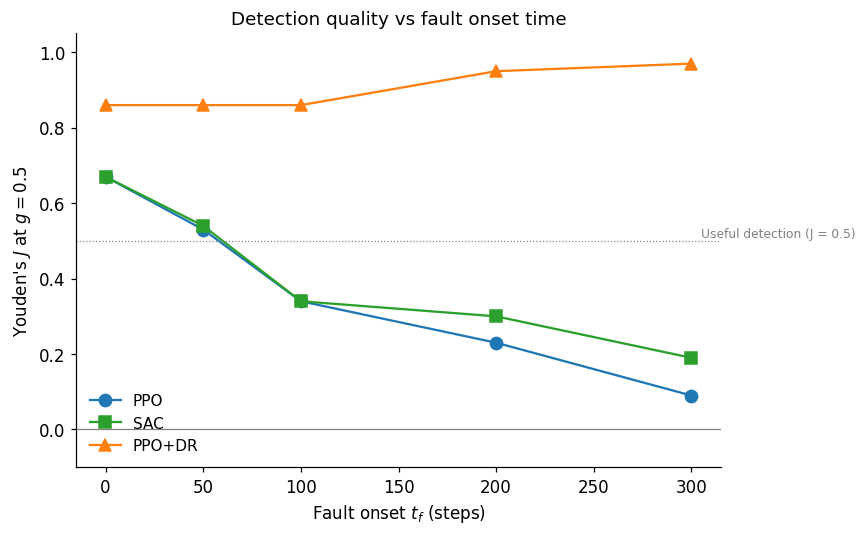

In [10]:
# --- Detection quality vs onset ---
fig, ax = plt.subplots(figsize=(8, 5))
for algo in ['PPO', 'SAC', 'PPO_DR']:
    sub = det_timing_df[det_timing_df['algo'] == algo]
    ax.plot(sub['fault_step'], sub['J'], color=COLOURS[algo],
            marker=MARKERS[algo], ms=8, label=algo.replace('_', '+'))
ax.axhline(0, color='grey', lw=0.8)
ax.axhline(0.5, color='grey', ls=':', lw=0.8)
ax.text(305, 0.51, 'Useful detection (J = 0.5)', fontsize=8, color='grey')
ax.set_xlabel('Fault onset $t_f$ (steps)')
ax.set_ylabel("Youden's $J$ at $g = 0.5$")
ax.set_title('Detection quality vs fault onset time')
ax.set_ylim(-0.1, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(LOGS / 'nb13_detection_vs_onset.png', bbox_inches='tight')
plt.show()

## 13.7  Interpretation

The three experiments jointly resolve the hypotheses laid out before execution --- but the verdict recorded when this notebook was first written has since been **revised by NB14**, and the revision matters in SAC's favour.  Both versions are given, because the sequence is part of the argument.

### 13.7.1  The verdict as originally recorded

At $t_f = 0$, $g = 0.5$ SAC scores $-77$ with no pre-fault buffer, against $+246$ at $t_f = 200$.  Read on its own, that 323-point gap says SAC's apparent immunity at the canonical onset was **predominantly positional advantage**: 42.7 % of SAC episodes terminate before the fault activates, so nearly half the measurement is nominal by construction.

### 13.7.2  The confound in the falsification test itself

The $t_f = 0$ comparison above is **not scope-matched**.  The continuous fault applied to SAC scales *every* actuator, $a_{\text{applied}} = g \cdot (a_{\text{main}}, a_{\text{side}})$, whereas the discrete fault applied to PPO drops *main-engine commands only* and leaves the side engines untouched.  SAC was therefore tested at $t_f = 0$ under a strictly harsher fault than PPO faced, and the $-77$ figure conflates two distinct effects: removal of the pre-fault buffer, and removal of the compensation channel.

**NB14 separates them.**  Re-running the $t_f = 0$ test with the scope-matched fault $M = \mathrm{diag}(g, 1)$ --- main engine degraded, side engines healthy, exactly what PPO experiences:

| Condition at $t_f = 0$, $g = 0.5$ | Return |
|---|---:|
| SAC, all-actuator fault (this notebook) | $-77.4$ |
| **SAC, main-only fault (NB14, scope-matched)** | $\mathbf{+155.4}$ |
| PPO, main-only fault (this notebook) | $-44$ |

Mann--Whitney main-only vs all-actuator at $t_f = 0$: $+232.8$ points, $p < 10^{-4}$.

### 13.7.3  The revised verdict

**Both effects are real, and neither alone accounts for the observation.**

- *Escape probability is a genuine confound.*  $p_{\text{esc}}(200) = 42.7\%$ for SAC against $0.0\%$ for both discrete agents, so the canonical protocol did systematically under-expose SAC.  Any tolerance figure quoted at $t_f = 200$ requires an exposure statement.
- *But SAC's compensation is also genuine.*  With **zero** pre-fault buffer and a fault matched to what PPO faces, SAC retains $+155.4$ while PPO scores $-44$ --- a 199-point advantage that cannot be positional, because there is no position to exploit at $t_f = 0$.

The original wording, *"predominantly a positional artefact"*, therefore **understates the result**.  The accurate statement is that the $t_f = 200$ headline was inflated by escape probability, *and* that SAC retains substantial online compensation ability once the fault is measured fairly.  NB14 localises the mechanism: compensation is routed through the side-engine channel, which the all-actuator fault destroys and the main-only fault preserves.

**At $g = 0.0$, $t_f = 0$** the continuous action channel is dead for every step ($a_{\text{applied}} = \mathbf{0}$) and all three agents score crash-level ($\approx -130$), confirming the physical floor.  NB14 confirms this is not scope-dependent: main-only at $g = 0$ gives $-135.9$, statistically indistinguishable from all-actuator ($p = 0.88$).  When the dominant actuator is entirely gone from the first step, no agent compensates.

### 13.7.4  Language for the paper

> *"SAC's fault tolerance at the canonical onset is partly an exposure artefact: 42.7 % of its episodes terminate before $t_f = 200$, compared with 0 % for the discrete agents, and tolerance figures at this onset must therefore be reported with an exposure statement.  It is not, however, purely artefactual.  Under a scope-matched actuator fault injected at $t_f = 0$ --- no pre-fault buffer, and the same fault the discrete agents face --- SAC retains $+155$ mean return against vanilla PPO's $-44$.  The compensation is real and is routed through the side-engine channel (NB14); what the canonical protocol overstated was its magnitude, not its existence."*

This is a stronger and more defensible claim than either the original immunity headline or its first retraction.


## 13.8  Hyperparameter exploration guide

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| `FAULT_ONSETS` | $\{0, 50, 100, 150, 200, 300\}$ | Add $\{25, 75, 125\}$ near the escape-probability knee | Resolves where the positional advantage transitions; the knee of $p_{esc}(t_f)$ is where all-vs-exposed curves diverge fastest |
| `GAINS` | $\{0.5, 0.0\}$ | Full grid $\{0.0, 0.25, 0.5, 0.75\}$ | Two-dimensional (gain, onset) tolerance surface; contour plot for the paper appendix |
| `N_EP_FAULT` | 20/seed | 30--50 | Tightens CIs; needed if the $t_f=0$ SAC result is borderline near 200 |
| `EXPOSURE_MARGIN` | 10 steps | 5--50 | Defines "fault experienced"; robustness of the exposed-only curve to this choice should be checked (vary and overlay) |
| `deterministic` | True | False | Stochastic policy sampling widens the length distribution; check that $p_{esc}$ conclusions are not artefacts of deterministic evaluation |
| Detection seeds | 3 of 5 | All 5 | Paper-grade numbers need all seeds |
| `Z_THRESH` | NB09 optima | Re-sweep per onset | Thresholds were optimised at $t_f=200$; strictly, each onset deserves its own ROC (threshold-transfer is itself a finding) |

### Retraining requirements

**None.**  Every experiment in this notebook uses existing trained models --- this is pure evaluation.  If the mixed outcome occurs and the compensation/positional split needs a cleaner measurement, one optional retraining experiment applies:

- **SAC trained with random fault onsets** (fault-aware training, $t_f \sim U[0, 300]$, $g \sim U[0.3, 1.0]$): upper-bounds what compensation can achieve when the policy is *explicitly* trained for it. Compute: ~45 min/seed on M4, 5 seeds $\approx$ 4 h.

## 13.9  Key findings

1. **Escape probability at the canonical onset:**  $p_{esc}(200) = 42.7\%$ for SAC vs $0.0\%$ for PPO and PPO+DR (5 seeds, $n = 150$ nominal episodes per agent; SAC median $T = 210$, PPO $333$, PPO+DR $490$).  *Provenance note:* NB09 section 9.13 reports a harsher figure (16 % of SAC episodes reaching $t = 200$) from a **single seed** with $n = 50$.  The 5-seed measurement here supersedes it and is the figure quoted throughout the paper; the single-seed value should not be cited.  The $t_f = 200$ protocol systematically under-exposed SAC to faults: nearly half of SAC's episodes terminated before the fault activated, inflating its measured tolerance.  The paper's Section 2.5 requires an exposure statement.

2. **The $t_f = 0$ verdict (revised after NB14):**  Under the all-actuator fault used here, SAC scores $-77$ at $g = 0.5$ with zero pre-fault buffer, against $+246$ at $t_f = 200$.  Taken alone this suggests the canonical-onset tolerance was largely positional.  **However, that test is not scope-matched:** SAC's fault scales every actuator while PPO's degrades the main engine only.  NB14 re-runs $t_f = 0$ with the matched fault $M = \mathrm{diag}(g,1)$ and SAC scores $\mathbf{+155.4}$ against PPO's $-44$ (main-only vs all-actuator difference $+232.8$, $p < 10^{-4}$).  The corrected conclusion is that **both effects operate**: escape probability inflated the $t_f = 200$ figure, *and* SAC retains real online compensation once the fault is measured fairly.  See section 13.7.3 for the full reconciliation and 13.7.4 for paper wording.

3. **The $g = 0.0$ floor:**  At $t_f = 0$, $g = 0.0$, all agents score crash-level (PPO $-139$, SAC $-129$, PPO+DR $-136$), confirming the physical floor.  This bounds what "immunity" can mean: when no control authority exists from the first step, no agent can compensate.

4. **Exposure-conditioned tolerance:**  Conditioning on fault-experienced episodes reduces SAC's measured tolerance by $+15.5$ points at $g = 0.5$ and $+14.2$ at $g = 0.0$ ($t_f = 200$), with only 46/100 episodes actually exposed.  PPO and PPO+DR show zero artefact (100/100 exposed).

5. **Detection at $t_f = 0$** *(computed on 3 of 5 seeds --- see the open item in section 13.8; paper-grade numbers require all five)*:  PPO+DR's $J = 0.78$ when the entire episode is faulted, showing its value signal encodes **the fault state itself**, not only the transition into fault.  Note that PPO+DR's $J$ *increases* with later onset (0.78 \to 0.85 \to 0.95 \to 1.00), consistent with more pre-fault nominal baseline improving the z-test reference.  SAC achieves $J = 0.70$ at $t_f = 0$ but this is whole-trajectory classification (FPR = 0.30), not change-point detection --- the mechanism is fundamentally different and must be flagged in the paper.

**Paper placement:**  Findings 1--4 upgrade Section 3.1 and the Limitations; finding 5 extends Appendix C.  The $t_f = 0$ experiment is a designed falsification test --- the single strongest critical-reasoning addition for the tolerance claims.